# Introduction

This notebook is an introduction to the ZoeDepth Monocular Depth Estimator. ZoeDepth has the ability to create depth maps out of a single image input. Instruction on how to install ZoeDepth can be found on their [github](https://github.com/isl-org/ZoeDepth) page. However, your python environment should at least satisfy the dependency requirements outlined in the environment.yaml on the same git repo. Also, the calling script should be called on the same level as the zoedepth folder. 

Images for testing are located in the **testImages** folder while the models will automaticallly be downloaded by your system and placed in a local directory eg. $HOME/.cache/torch/hub/checkpoints for linux systems.


In [1]:
import torch
from zoedepth.models.builder import build_model
from zoedepth.utils.config import get_config
from zoedepth.utils.misc import colorize
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import cv2

%matplotlib notebook

## Model choice
The ZoeD_N pretrained model is chosen for this task. It is trained on the NYUv2 dataset which contains indoor images.

Given that the whose depth map are to be computed for this project are from the interior of a building, a model trained on an Indoor dataset is the preferred choice.


In [17]:
# Load the ZoeD_N pretrained Model
conf = get_config("zoedepth", "infer")
model_zoe_n = build_model(conf)

##### sample prediction
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
zoe = model_zoe_n.to("cpu")
maps_dict = dict()

img_size [384, 512]


Using cache found in /home/kibzyzii/.cache/torch/hub/intel-isl_MiDaS_master


Params passed to Resize transform:
	width:  512
	height:  384
	resize_target:  True
	keep_aspect_ratio:  True
	ensure_multiple_of:  32
	resize_method:  minimal
Using pretrained resource url::https://github.com/isl-org/ZoeDepth/releases/download/v1.0/ZoeD_M12_N.pt
Loaded successfully


## Helper Functions

The `compute_depth` function calls the zoe_depth backend to compute a depth map based on the image provided.

The `compare_maps` function plots a base image and its corresponding depth image.

In [15]:
def load_image(img_name, img_dir="testImages/"):
    """
    Loads in an image from the file system

    Args:
    - img_name (string): File name of the image.
    - img_dir (string): The relative directory in which the image is contained.

    Returns:
    - numpy.ndarray: The image as a 2D numpy array
    """
    return cv2.cvtColor(cv2.imread(img_dir+img_name), cv2.COLOR_BGR2RGB)

def compute_depth(image):    
    depth_numpy = zoe.infer_pil(image)  # as numpy
    return depth_numpy
    
def compare_maps(image, depth_map, map_title="Depth Map"):
    colored_depth = colorize(depth_map)
    fig, axs = plt.subplots(1,2, figsize=(15,7))
    for ax, im, title in zip(axs, [image, colored_depth], ['Base Image', map_title]):
      ax.imshow(im)
#       ax.axis('off')
      ax.set_title(title)
    
def show_depth_point(_map, ax, x, y, offset=2):
    ax.scatter(x, y, marker="o")
    ax.text( x+offset, y+offset, np.round( _map[y][x], 3), bbox=dict(facecolor='white', alpha=0.5) )

## Sample 1
The result images may depicts the floor to be closer than the objects itself. That is not entirely the case.

The floor is also mapped. This can cause confusion when computing face normals.

## Recommendations
Isolate regions of interest within the images.

SunRGBD lib for pixel level segmentation.

Compare with other depth map generators

## Image 37

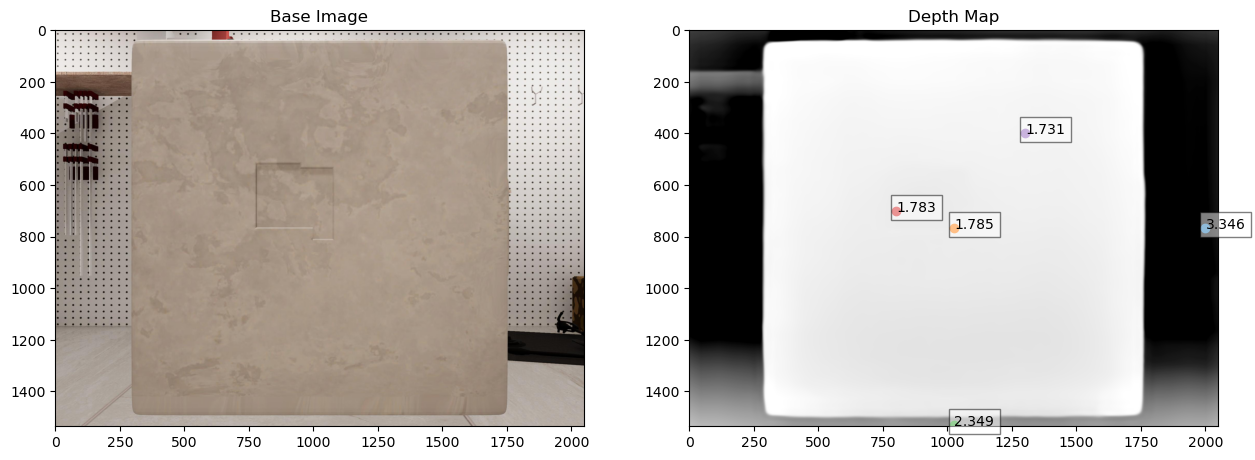

In [40]:
_image = "37.jpg"
maps_dict[_image] = compute_depth(load_image(_image))
compare_maps( load_image(_image), maps_dict[_image] ) 

show_depth_point( maps_dict[_image], plt.gca(), 2000, 768 )
show_depth_point( maps_dict[_image], plt.gca(), 1024, 768 )
show_depth_point( maps_dict[_image], plt.gca(), 1024, 1530 )
show_depth_point( maps_dict[_image], plt.gca(), 800, 700 )
show_depth_point( maps_dict[_image], plt.gca(), 1300, 400 )

### Observations

- The inset on the obects face is "undiscernable."
- The floor area has been captured to a significantly.
- The shelf at the top left area has been captured too.
- Event if the inset has been indeed captured the shelf and the floor would demean it.

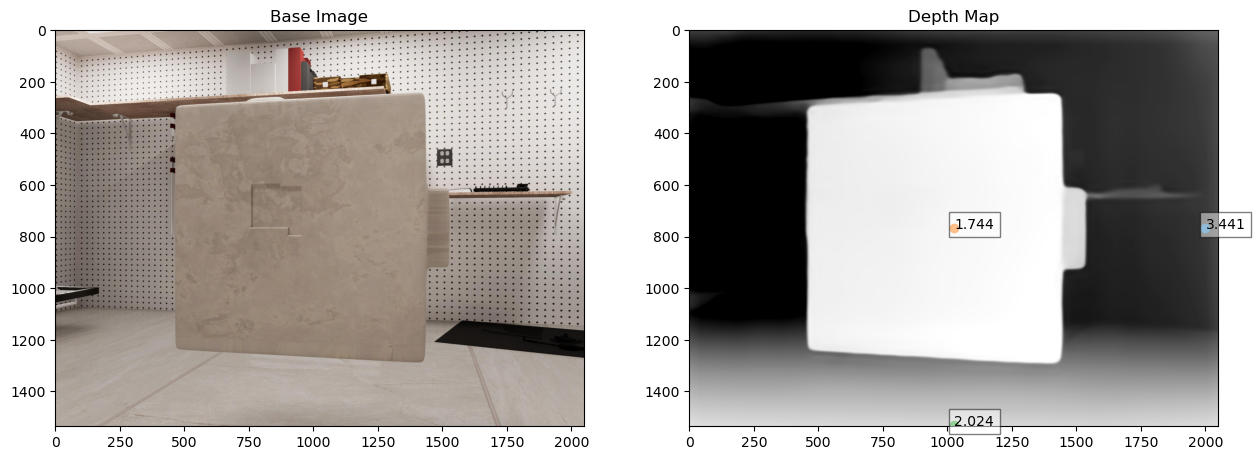

In [41]:
_image = "2.jpg"
maps_dict[_image] = compute_depth(load_image(_image))
compare_maps( load_image(_image), maps_dict[_image] ) 

show_depth_point( maps_dict[_image], plt.gca(), 2000, 768 )
show_depth_point( maps_dict[_image], plt.gca(), 1024, 768 )
show_depth_point( maps_dict[_image], plt.gca(), 1024, 1530 )

### Observations
- Similar to image 37 but at a slightly different angle and at a larger working distance.
- Some parts of the shelves are still be captured.
- There is a contrast between the oobject on protrustion on the right of the object and the shelf.

## Image 43

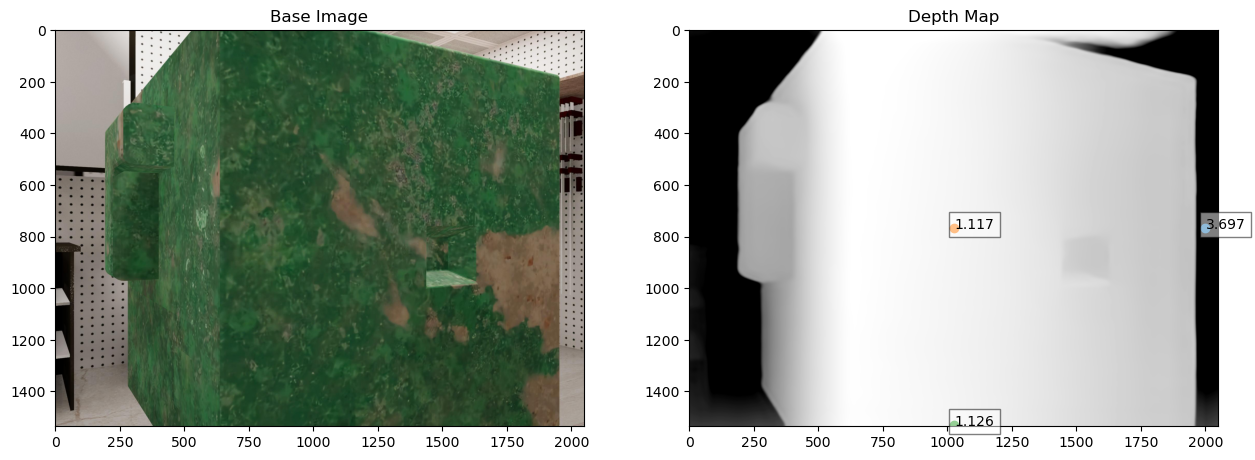

In [42]:
_image = "43.jpg"
maps_dict[_image] = compute_depth(load_image(_image))
compare_maps( load_image(_image), maps_dict[_image] ) 

show_depth_point( maps_dict[_image], plt.gca(), 2000, 768 )
show_depth_point( maps_dict[_image], plt.gca(), 1024, 768 )
show_depth_point( maps_dict[_image], plt.gca(), 1024, 1530 )

### Observations
- Notice that most of the background is all blacked out.
- However, there is a section on the roof that is computed. That should be an outlier.

## Image 33

Image 33 contains 2 inset features.

In [16]:
_image = "33.jpg"
maps_dict[_image] = compute_depth(load_image(_image))
compare_maps( load_image(_image), maps_dict[_image] ) 

show_depth_point( maps_dict[_image], plt.gca(), 2000, 768 )
show_depth_point( maps_dict[_image], plt.gca(), 1750, 1200 )
show_depth_point( maps_dict[_image], plt.gca(), 500, 1530 )

OutOfMemoryError: CUDA out of memory. Tried to allocate 96.00 MiB (GPU 0; 5.80 GiB total capacity; 3.04 GiB already allocated; 118.25 MiB free; 3.23 GiB reserved in total by PyTorch) If reserved memory is >> allocated memory try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF

### Observations
- The 2 inset features are visible.
- There is a distinction between the floor and the target object-the left half of the bottom of the image 

## Downstream Processing Methodology

The cell below highlights some of the ways in which downstream procesing may be handled. It aims to reduce the higher resolution image into a lower one with a group of pixels averaged out. For the case below, an input image is reduced to a 15 * 20 cell grid from the initial resolution of the image. A depth map of the input image is first calculated then translated to the 15 by 20 grid with a colour map.

This averaging in a sense reduces noise of the depth map. Convolution is a better way of going about this since it allows for a varied filters to be used that can  bring out a number of features of the image.


The grid with the highest average is at index: (2, 5), with an average of: 3.863149404525757


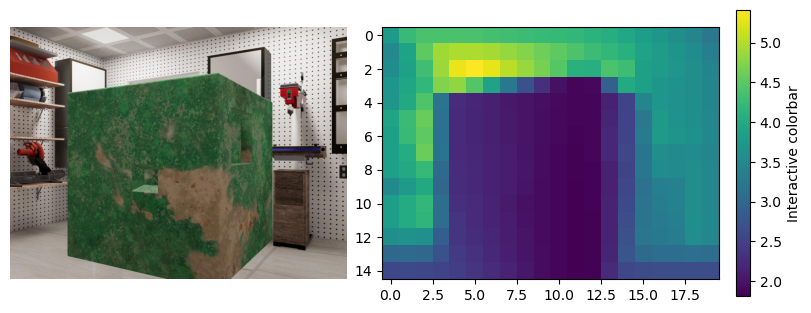

In [48]:
img_name = "33.jpg"

img_arr = maps_dict[img_name]

height, width = maps_dict[img_name].shape

gridSize = (15,20)

# 1. Get Cell dimensions
vert_pixels_pgrid = int(height/gridSize[0])
hor_pixels_pgrid = int(width/gridSize[1])

# 2. Compute the averages for each 153x204 grid
averages = np.zeros(gridSize)  # Create an empty 9x12 array to store averages

for i in range(gridSize[0]):
    for j in range(gridSize[1]):
        #img_arr[ row_range, col_range ]
        small_grid = img_arr[i*vert_pixels_pgrid:(i+1)*vert_pixels_pgrid, j*hor_pixels_pgrid:(j+1)*hor_pixels_pgrid]
        averages[i, j] = np.mean(small_grid)

# 4. Find the grid (index) with the highest average
max_avg_index = np.unravel_index(averages.argmax(), averages.shape)

print(f"The grid with the highest average is at index: {max_avg_index}, with an average of: {averages[6][0]}")

fig, axs = plt.subplots(1,2, figsize=(8,3), layout="constrained")

axs[0].imshow( load_image(img_name) )
axs[0].axis("off")
colplot =  axs[1].imshow( averages )
fig.colorbar(colplot, ax=axs[1], label='Interactive colorbar')

# Displaying the plot
plt.show()

# Midas



In [3]:
model_type = "DPT_BEiT_L_512"
midas = torch.hub.load("intel-isl/MiDaS", model_type)

Using cache found in /home/kibzyzii/.cache/torch/hub/intel-isl_MiDaS_master
/opt/miniconda3/envs/zoe/lib/python3.9/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /opt/conda/conda-bld/pytorch_1670525539683/work/aten/src/ATen/native/TensorShape.cpp:3190.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [47]:
dev = torch.device("cpu") if torch.cuda.is_available() else torch.device("cpu")
midas.to(dev)
midas.eval()

midas_transforms = torch.hub.load( "intel-isl/MiDaS", "transforms")

if model_type == "DPT_BEiT_L_512":
  transform  = midas_transforms.beit512_transform
elif model_type == "DPT_Hyrid":
  transform  = midas_transforms.default_transform
else:
  transfrom = midas_transforms.small_transform

img = load_image("33.jpg")

input_batch = transform(img).to(dev)
import time
start = time.time()
with torch.no_grad():
  prediction = midas(input_batch)

  prediction = torch.nn.functional.interpolate(
      prediction.unsqueeze(1),
      size=img.shape[:2],
      mode="bicubic",
      align_corners=False
  ).squeeze()
output = prediction.cpu().numpy()
print(time.time() -start)

Using cache found in /home/kibzyzii/.cache/torch/hub/intel-isl_MiDaS_master


7.166491746902466


<IPython.core.display.Javascript object>


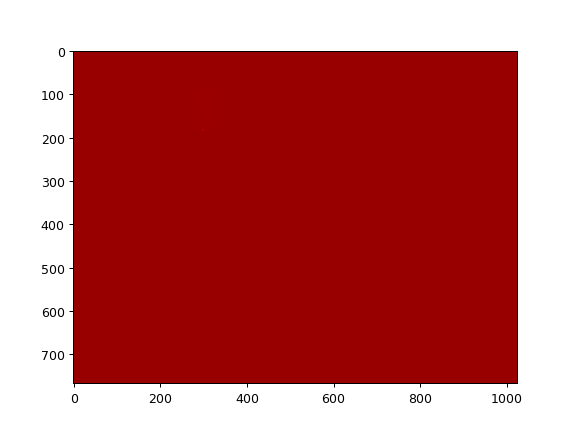

In [70]:
row_index, col_index = np.unravel_index(np.argmax(output), output.shape)
gt_depth = .95
sf = (1/gt_depth)/(output[row_index,col_index])
inv_output = output*sf
plt.figure()
plt.imshow(1/inv_output, cmap='hot')

In [63]:
output[row_index,col_index]

7760.77

In [25]:
zoe_res = compute_depth(img)

<IPython.core.display.Javascript object>


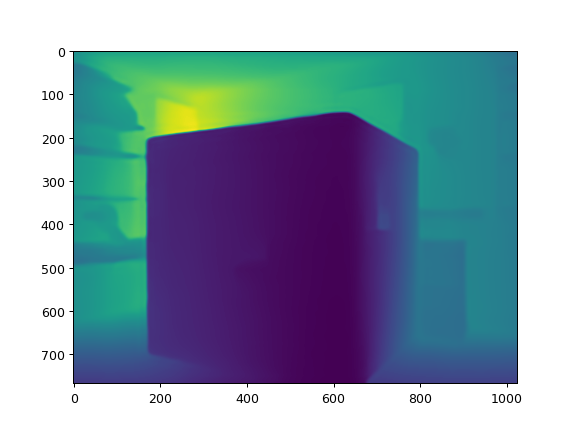

In [32]:
plt.figure()
plt.imshow(zoe_res, cmap="viridis")

In [52]:
output.shape

(768, 1024)

In [69]:
(1/inv_output)[row_index,col_index]

0.95